In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Momentum Shift Detection in IPL Matches using Over-by-Over Win Probability

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [64]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [65]:
sns.set(style="whitegrid")


balls = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")

team_map = {
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Pune Warriors': 'Rising Pune Supergiant',
    'Gujarat Lions': 'Gujarat Titans'
}
balls['bowling_team'] = balls['bowling_team'].replace(team_map)
balls['batting_team'] = balls['batting_team'].replace(team_map)
matches['team1'] = matches['team1'].replace(team_map)
matches['team2'] = matches['team2'].replace(team_map)
matches['toss_winner'] = matches['toss_winner'].replace(team_map)
matches['winner'] = matches['winner'].replace(team_map)
balls.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [66]:
balls.rename(columns={"match_id": "id"}, inplace=True)

balls.head()

,id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [67]:
match_info = matches[["id", "season", "team1", "team2", "winner", "venue"]]

balls = balls.merge(match_info, on="id", how="left")

balls.head()

,id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,season,team1,team2,winner,venue
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,legbyes,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,wides,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium


In [68]:
over_data = balls.groupby(["id", "inning", "over"]).agg(
    runs=("total_runs", "sum"),
    wickets=("is_wicket", "sum")
).reset_index()

over_data["cum_runs"] = over_data.groupby(["id", "inning"])["runs"].cumsum()
over_data["cum_wickets"] = over_data.groupby(["id", "inning"])["wickets"].cumsum()

over_data.head()

,id,inning,over,runs,wickets,cum_runs,cum_wickets
0,335982,1,0,3,0,3,0
1,335982,1,1,18,0,21,0
2,335982,1,2,6,0,27,0
3,335982,1,3,23,0,50,0
4,335982,1,4,10,0,60,0


In [69]:
first_innings = over_data[over_data["inning"] == 1].groupby("id").agg(
    first_innings_score=("runs", "sum")
).reset_index()

first_innings["target"] = first_innings["first_innings_score"] + 1

over_data = over_data.merge(first_innings[["id", "target"]], on="id", how="left")

In [70]:
team_over = balls.groupby(["id", "inning", "over"]).agg(
    batting_team=("batting_team", "first"),
    bowling_team=("bowling_team", "first"),
    winner=("winner", "first")
).reset_index()

over_data = over_data.merge(team_over, on=["id", "inning", "over"], how="left")

In [71]:
over_data["overs_completed"] = over_data["over"] + 1
over_data["balls_remaining"] = (20 - over_data["overs_completed"]) * 6
over_data["wickets_remaining"] = 10 - over_data["cum_wickets"]
over_data["current_run_rate"] = over_data["cum_runs"] / over_data["overs_completed"]
over_data["runs_required"] = over_data["target"] - over_data["cum_runs"]
over_data["required_run_rate"] = (over_data["runs_required"] * 6) / over_data["balls_remaining"].replace(0, np.nan)
over_data["required_run_rate"].fillna(0, inplace=True)

0        11.578947
1        11.222222
2        11.529412
3        10.812500
4        10.866667
           ...    
42205     2.307692
42206     1.750000
42207     0.727273
42208     0.300000
42209     0.000000
Name: required_run_rate, Length: 42210, dtype: float64

In [72]:
over_data["batting_team_win"] = np.where(
    over_data["batting_team"] == over_data["winner"], 1, 0
)

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = [
    "inning", "over", "cum_runs", "cum_wickets",
    "wickets_remaining", "balls_remaining",
    "current_run_rate", "runs_required", "required_run_rate"
]

model_data = over_data.dropna()

X = model_data[features]
y = model_data["batting_team_win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
model_data["win_probability"] = model.predict_proba(X)[:, 1] * 100

In [75]:
#match_id = model_data["id"].iloc[0]
#match_id = 335982
# Find matches with high momentum change
model_data["momentum_change"] = model_data.groupby(["id", "inning"])["win_probability"].diff()

volatility = model_data.groupby("id")["momentum_change"].apply(
    lambda x: x.abs().mean()
).reset_index()

volatility.columns = ["id", "volatility"]

# Pick best match
match_id = volatility.sort_values("volatility", ascending=False).iloc[0]["id"]

match = model_data[model_data["id"] == match_id].copy()

In [76]:
match["momentum_change"] = match.groupby("inning")["win_probability"].diff()

In [77]:
balls.head()

,id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,season,team1,team2,winner,venue
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,legbyes,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,wides,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,2007/08,Royal Challengers Bengaluru,Kolkata Knight Riders,Kolkata Knight Riders,M Chinnaswamy Stadium


In [78]:
match.head()

,id,inning,over,runs,wickets,cum_runs,cum_wickets,target,batting_team,bowling_team,winner,overs_completed,balls_remaining,wickets_remaining,current_run_rate,runs_required,required_run_rate,batting_team_win,win_probability,momentum_change
24348,1082650,1,0,3,0,3,0,130,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,1,114,10,3.00,127,6.684211,1,71.702381,NaN
24349,1082650,1,1,4,0,7,0,130,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,2,108,10,3.50,123,6.833333,1,65.000000,-6.702381
24350,1082650,1,2,2,2,9,2,130,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,3,102,8,3.00,121,7.117647,1,77.000000,12.000000
24351,1082650,1,3,2,0,11,2,130,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,4,96,8,2.75,119,7.437500,1,25.000000,-52.000000
24352,1082650,1,4,5,0,16,2,130,Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,5,90,8,3.20,114,7.600000,1,18.000000,-7.000000


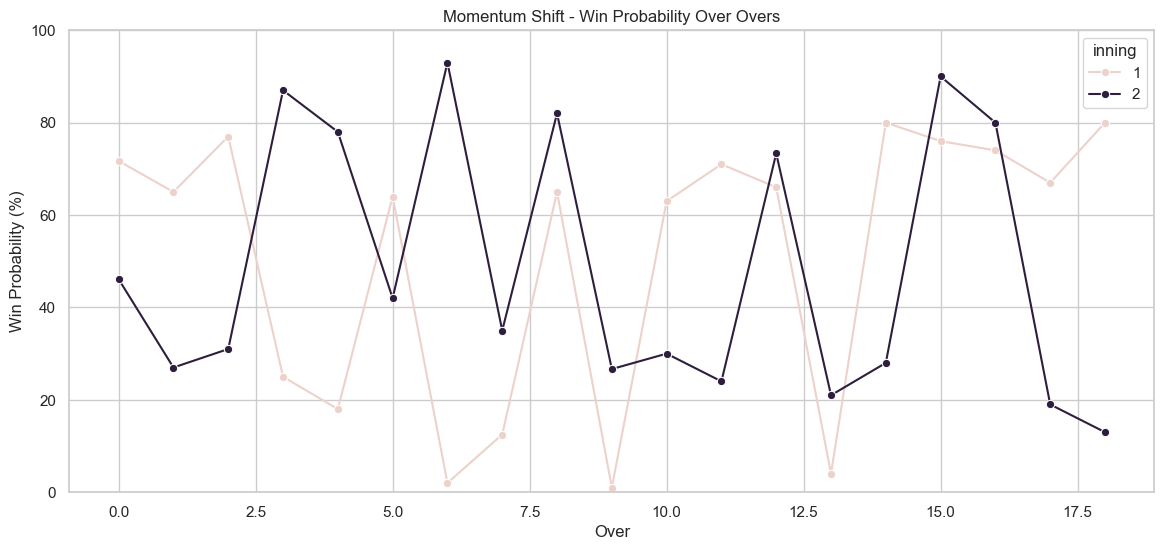

In [79]:
plt.figure(figsize=(14,6))

sns.lineplot(data=match, x="over", y="win_probability", hue="inning", marker="o")

plt.title("Momentum Shift - Win Probability Over Overs")
plt.xlabel("Over")
plt.ylabel("Win Probability (%)")
plt.ylim(0,100)

plt.show()

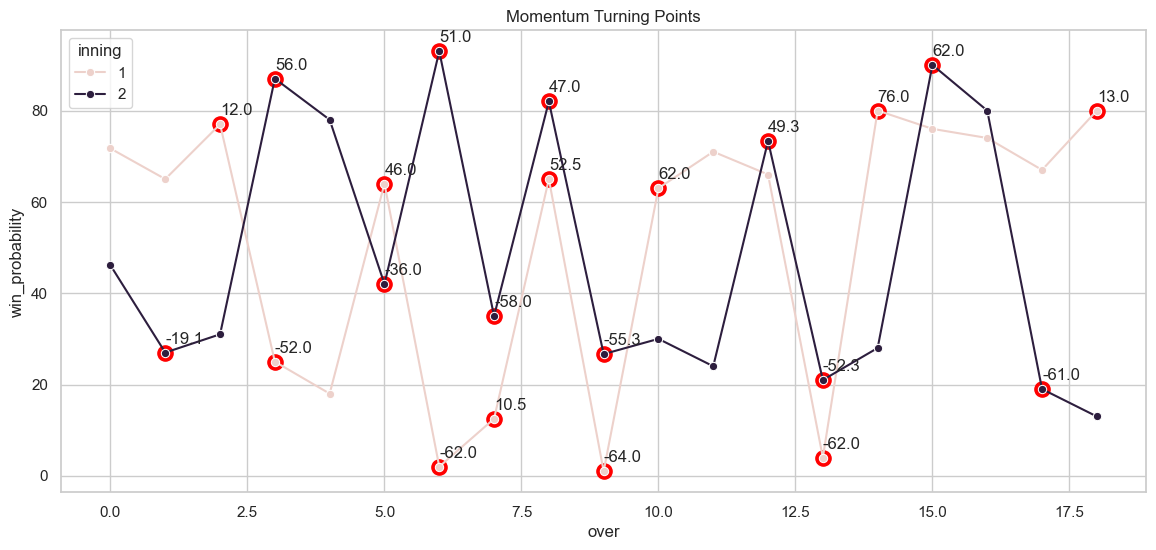

In [80]:
big_shift = match[abs(match["momentum_change"]) > 10]

plt.figure(figsize=(14,6))

sns.lineplot(data=match, x="over", y="win_probability", hue="inning", marker="o")

plt.scatter(big_shift["over"], big_shift["win_probability"], color="red", s=120)

for _, row in big_shift.iterrows():
    plt.text(row["over"], row["win_probability"]+2, f"{row['momentum_change']:.1f}")

plt.title("Momentum Turning Points")
plt.show()

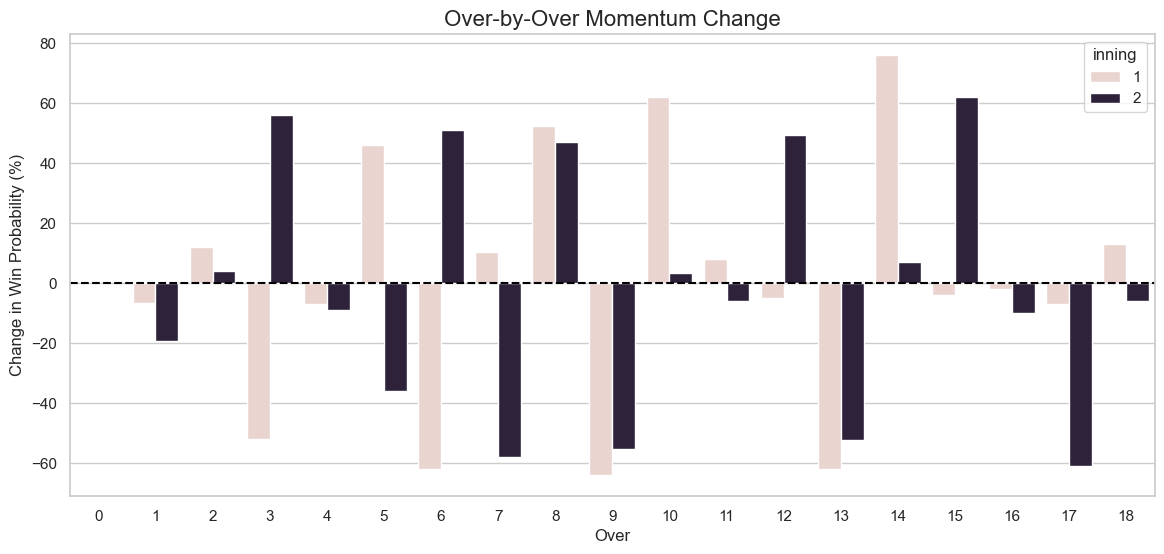

In [81]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=match,
    x="over",
    y="momentum_change",
    hue="inning"
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Over-by-Over Momentum Change", fontsize=16)
plt.xlabel("Over")
plt.ylabel("Change in Win Probability (%)")

plt.show()

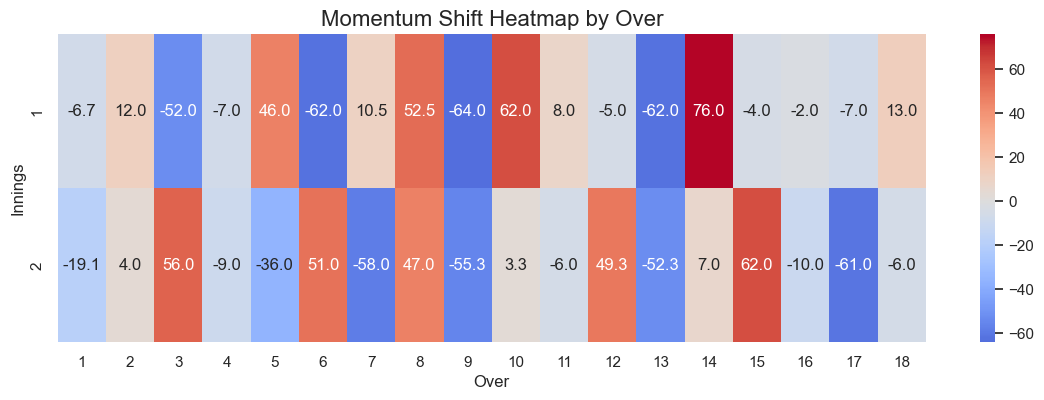

In [82]:
heatmap_data = match.pivot_table(
    index="inning",
    columns="over",
    values="momentum_change"
)

plt.figure(figsize=(14, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0
)

plt.title("Momentum Shift Heatmap by Over", fontsize=16)
plt.xlabel("Over")
plt.ylabel("Innings")

plt.show()

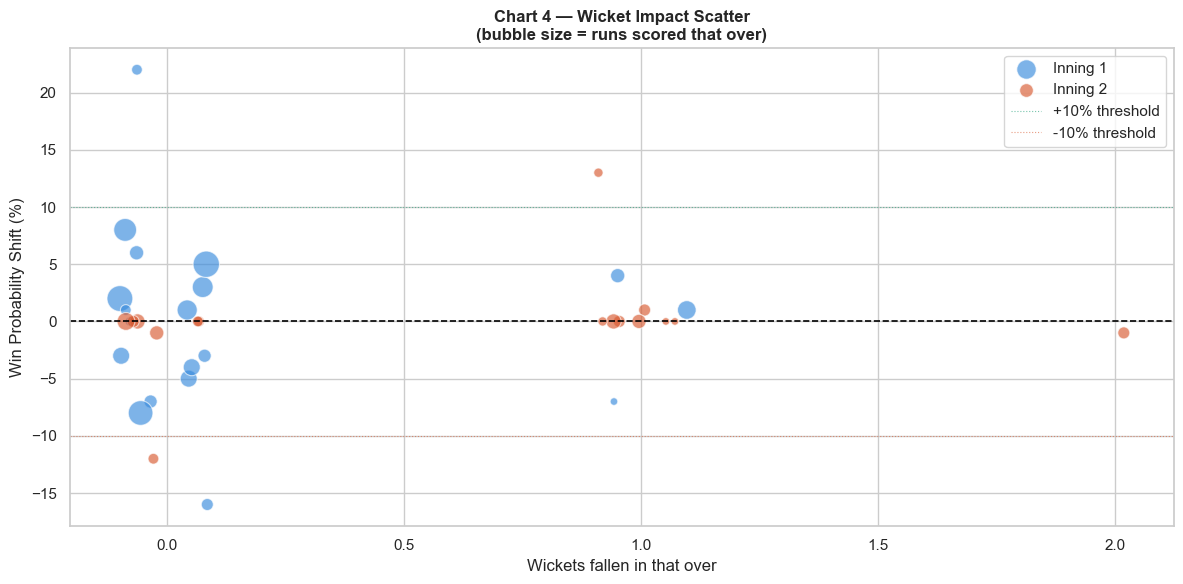

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))
 
for inn_df, color, label in [(inn1, "#378ADD", "Inning 1"), (inn2, "#D85A30", "Inning 2")]:
    wkts  = inn_df["wickets"].fillna(0).values if "wickets" in inn_df.columns else inn_df["cum_wickets"].diff().fillna(0).values
    shift = inn_df["momentum_change"].fillna(0).values
    runs  = inn_df["runs"].fillna(0).values if "runs" in inn_df.columns else inn_df["cum_runs"].diff().fillna(0).values
    sizes = np.clip(np.abs(runs) * 15, 30, 600)
 
    sc = ax.scatter(wkts + np.random.uniform(-0.1, 0.1, len(wkts)),
                    shift, s=sizes, alpha=0.65,
                    color=color, edgecolors="white", linewidth=0.8, label=label)
 
ax.axhline(0, color="black", lw=1.2, linestyle="--")
ax.axhline(10,  color="#1D9E75", lw=0.8, linestyle=":", alpha=0.6, label="+10% threshold")
ax.axhline(-10, color="#D85A30", lw=0.8, linestyle=":", alpha=0.6, label="-10% threshold")
ax.set_xlabel("Wickets fallen in that over")
ax.set_ylabel("Win Probability Shift (%)")
ax.set_title("Chart 4 — Wicket Impact Scatter\n(bubble size = runs scored that over)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

| Over | Runs | Wickets | Momentum Change |        
| ---- | ---- | ------- | --------------- |
| 1    | 5    | 0       | +2%             | 
| 2    | 12   | 1       | +6%             |
| 3    | 3    | 2       | -15%            |
| 4    | 8    | 0       | -3%             |

| Wickets (X) | Momentum (Y) |
| ----------- | ------------ |
| 0           | +2%          |
| 1           | +6%          |
| 2           | -15%         |
| 0           | -3%          |


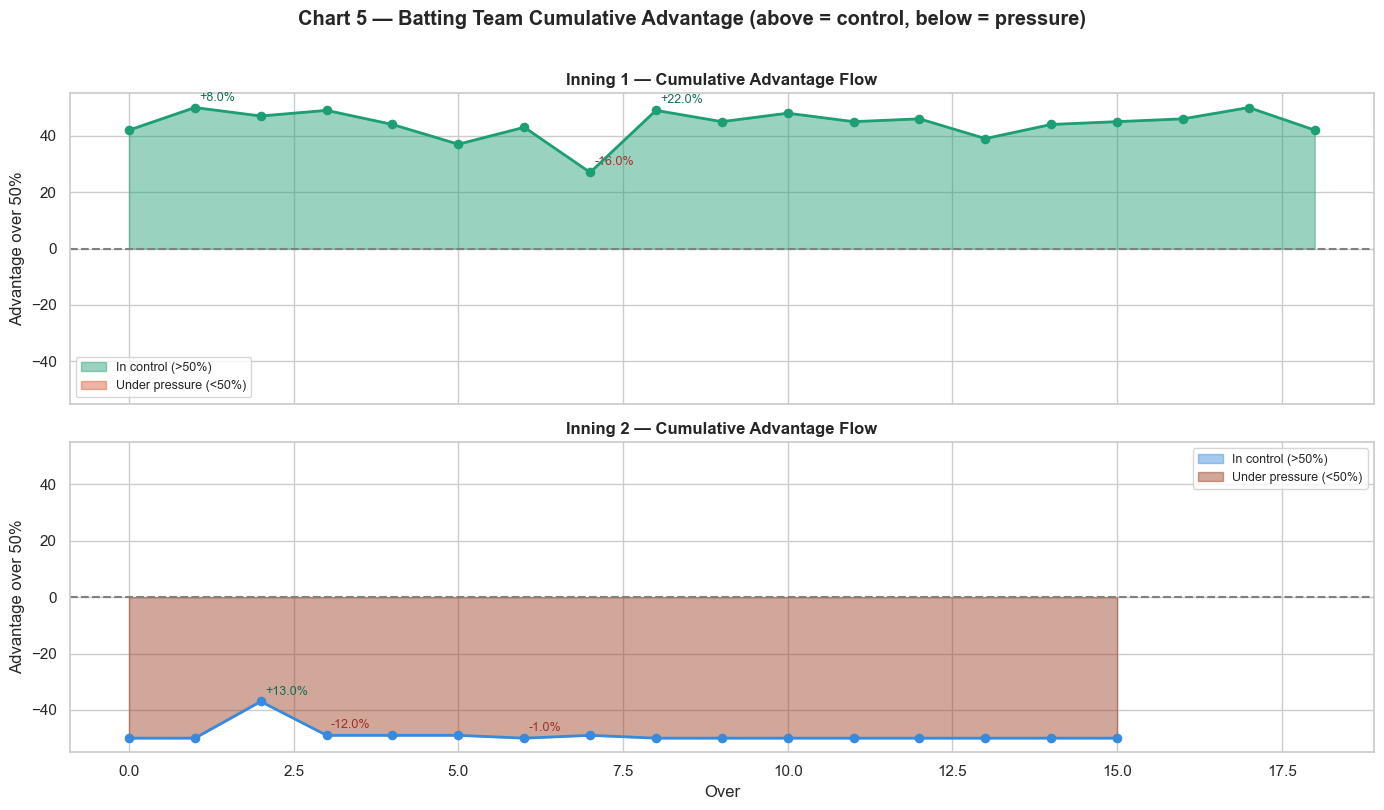

In [84]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
 
for ax, inn_df, label, c_pos, c_neg in zip(
    axes,
    [inn1, inn2],
    ["Inning 1", "Inning 2"],
    ["#1D9E75", "#378ADD"],
    ["#D85A30", "#993C1D"]
):
    overs = inn_df["over"].values
    wp    = inn_df["win_probability"].values
    adv   = wp - 50  
    ax.fill_between(overs, adv, 0, where=(adv >= 0), interpolate=True,
                    alpha=0.45, color=c_pos, label="In control (>50%)")
    ax.fill_between(overs, adv, 0, where=(adv < 0),  interpolate=True,
                    alpha=0.45, color=c_neg, label="Under pressure (<50%)")
    ax.plot(overs, adv, color=c_pos, lw=2, zorder=4)
    ax.scatter(overs, adv, s=35, color=c_pos, zorder=5)
 
    mc = inn_df["momentum_change"].fillna(0)
    for idx in mc.abs().nlargest(3).index:
        row = inn_df.loc[idx]
        val = mc.loc[idx]
        ax.annotate(f"{val:+.1f}%",
                    xy=(row["over"], row["win_probability"] - 50),
                    xytext=(3, 5), textcoords="offset points",
                    fontsize=9, color="#A32D2D" if val < 0 else "#0F6E56")
 
    ax.axhline(0, color="gray", lw=1.5, linestyle="--")
    ax.set_ylabel("Advantage over 50%")
    ax.set_title(f"{label} — Cumulative Advantage Flow", fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(-55, 55)
 
axes[-1].set_xlabel("Over")
plt.suptitle("Chart 5 — Batting Team Cumulative Advantage (above = control, below = pressure)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
balls